# Problem Set 3: Linear Regression and Classification with Movies Dataset
## BUS 659


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

/Users/matthewtonks/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/cg/drmdpssj7b1g61ncm5ng3gww0000gn/T/matplotlib-yh7t3zuy because there was an issue with the default path (/Users/matthewtonks/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Load the movies dataset
df = pd.read_csv('/datasets/movies_dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3000, 21)


,movie_title,original_title,director_name,actor_1_name,actor_2_name,actor_3_name,budget,gross,title_year,release_date,...,vote_average,vote_count,popularity,genres,country,original_language,overview,tagline,tmdb_id,imdb_id
0,Animale,Animale,Emma Benestan,Oulaya Amamra,Damien Rebattel,Vivien Rodriguez,3800000,71924,2024,2024-09-20,...,6.806,18,48.6594,Fantasy|Drama|Horror,Belgium|France,fr,"Camargue, France - Nejma trains hard to win th...",NaN,1020822,tt27503400
1,Deadpool & Wolverine,Deadpool & Wolverine,Shawn Levy,Ryan Reynolds,Hugh Jackman,Emma Corrin,200000000,1338073645,2024,2024-07-24,...,7.600,7669,42.3129,Action|Comedy|Science Fiction,United States of America,en,A listless Wade Wilson toils away in civilian ...,Come together.,533535,tt6263850
2,Sonic the Hedgehog 3,Sonic the Hedgehog 3,Jeff Fowler,Jim Carrey,Ben Schwartz,Keanu Reeves,122000000,492162604,2024,2024-12-19,...,7.666,2908,39.7000,Action|Science Fiction|Comedy|Family,United States of America|Japan,en,"Sonic, Knuckles, and Tails reunite against a p...",New adventure. New rival.,939243,tt18259086
3,The Wild Robot,The Wild Robot,Chris Sanders,Lupita Nyong'o,Pedro Pascal,Kit Connor,78000000,331982078,2024,2024-09-12,...,8.314,5315,32.9376,Animation|Science Fiction|Family,United States of America,en,"After a shipwreck, an intelligent robot called...",Discover your true nature.,1184918,tt29623480
4,Mufasa: The Lion King,Mufasa: The Lion King,Barry Jenkins,Aaron Pierre,"Kelvin Harrison, Jr.",Tiffany Boone,200000000,722631756,2024,2024-12-18,...,7.369,2340,31.6705,Adventure|Family|Animation,United States of America,en,"Mufasa, a cub lost and alone, meets a sympathe...",The story of an orphan who would be king.,762509,tt13186482


## Part 1: Linear Regression - Predicting Movie Gross Revenue

### Question 1: Data Preparation and Feature Engineering (12 points)

#### Q1.a) Clean the dataset by removing rows with missing values in key columns: gross, budget, vote_average, and duration. How many rows remain? (2 points)

In [ ]:
# Your code here
df_clean = df.dropna(subset=['gross', 'budget', 'vote_average', 'duration'])
print(f"Rows remaining after cleaning: {df_clean.shape[0]}")



Rows remaining after cleaning: 3000


#### Q1.b) Extract the first genre from the 'genres' column (genres are separated by '|'). Create a new column called 'first_genre'. Show the top 5 most common genres. (3 points)

In [4]:
# Your code here
df_clean['first_genre'] = df_clean['genres'].str.split('|', expand=True)[0]
print('first genres count:', len(df_clean['first_genre'].unique()))


first genres count: 20


#### Q1.c) Similarly, extract 'country_first' from the 'country' column and 'language_first' from 'original_language'. Handle any missing values appropriately. (2 points)

In [5]:
# Your code here

# Your code here
df_clean['first_country'] = df_clean['country'].str.split('|', expand=True)[0]
print('first countries count:', len(df_clean['first_country'].unique()))

df_clean['language_first'] = df_clean['original_language'].str.split('|', expand=True)[0]
print('first languages count:', len(df_clean['language_first'].unique()))

first countries count: 98
first languages count: 66


#### Q1.d) Create dummy variables for categorical features: first_genre, country_first (only for USA vs others), and language_first (only for English vs others). (3 points)

In [6]:
# Your code here

# Create dummy variable for first_genre (one-hot encoding)
genre_dummies = pd.get_dummies(df_clean['first_genre'], prefix='genre')

# Create binary dummy for country_first: is_usa (1 if USA, 0 otherwise)
df_clean['is_usa'] = (df_clean['first_country'] == 'United States of America').astype(int)

# Create binary dummy for language_first: is_english (1 if English, 0 otherwise)
df_clean['is_english'] = (df_clean['language_first'] == 'en').astype(int)

# Concatenate genre dummies to the dataframe
df_clean = pd.concat([df_clean, genre_dummies], axis=1)

# Display the first few rows to verify
df_clean[['first_genre', 'is_usa', 'is_english'] + list(genre_dummies.columns)].head()

,first_genre,is_usa,is_english,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,...,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
0,Fantasy,0,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Action,1,1,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Action,1,1,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Animation,1,1,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Adventure,1,1,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### Q1.e) Split the data into training (75%) and testing (25%) sets. Use random_state=42 for reproducibility. (2 points)

In [7]:
    # Your code here
train_df, test_df = train_test_split(df_clean, test_size=0.25, random_state=42)

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (2250, 45)
Testing set shape: (750, 45)


### Question 2: Building and Evaluating Linear Regression Models (12 points)

#### Q2.a) Build a linear regression model predicting gross revenue using: budget, title_year, is_usa, is_english, vote_average, and duration. Display the model summary. (3 points)

In [8]:
# Your code here
mod = smf.ols("gross ~ budget + title_year + is_usa + is_english + vote_average + duration" , 
data=train_df).fit()

# --- In-sample predictions (training data) ---
preds_train = mod.predict(train_df)

print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:                  gross   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     537.9
Date:                Wed, 01 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:01:42   Log-Likelihood:                -45081.
No. Observations:                2250   AIC:                         9.018e+04
Df Residuals:                    2243   BIC:                         9.022e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     4.825e+09   1.81e+09      2.666   

#### Q2.b) Calculate RMSE for both training and testing sets. What do these values tell you about model performance? (3 points)

In [9]:
# Your code here
rmse_train = np.sqrt(np.mean((train_df['gross'] - preds_train) ** 2))
print(f"Training RMSE: {rmse_train}")

rmse_test = np.sqrt(np.mean((test_df['gross'] - mod.predict(test_df)) ** 2))
print(f"Testing RMSE: {rmse_test}")

Training RMSE: 121676163.060897
Testing RMSE: 114112520.62057497


### Answer:

For the RMSE values we can see that on average the model is going to be off by that $121676163.060897 for the training set and $114112520 for the testing set.

The lower value on the testing shows that there is a low chance that the model is over fit.

WIth the inclusion of Blockbuster type movies in the model this error can be expected from the data set

#### Q2.c) Create a scatter plot of predicted vs actual gross revenue for the test set using seaborn. Add a diagonal reference line. (3 points)

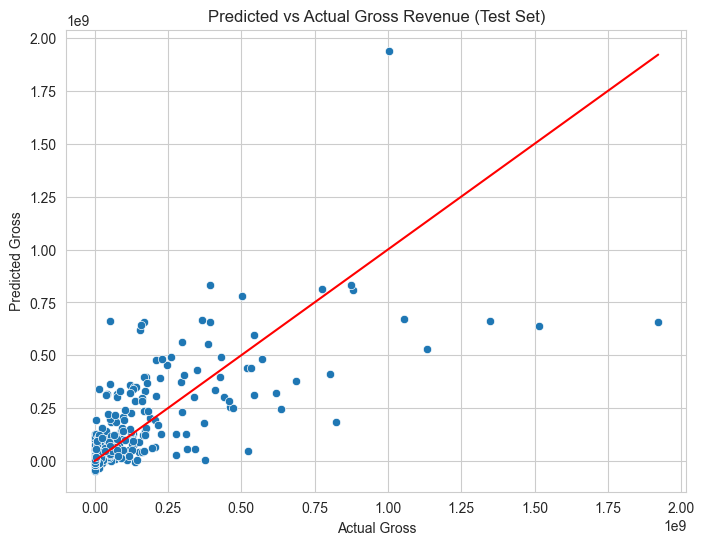

In [10]:
# Your code here
sns.scatterplot(x=test_df['gross'], y=mod.predict(test_df))
plt.xlabel('Actual Gross')
plt.ylabel('Predicted Gross')
plt.title('Predicted vs Actual Gross Revenue (Test Set)')
plt.plot([test_df['gross'].min(), test_df['gross'].max()],
         [test_df['gross'].min(), test_df['gross'].max()],
         color='red')
plt.show()

#### Q2.d) Build a log-log model: log(gross) ~ log(budget). Interpret the coefficient on log(budget) using the elasticity formula. What does a 1% increase in budget lead to? (3 points)

In [11]:
# Your code here
df_clean['log_gross'] = np.log1p(df_clean['gross'])
df_clean['log_budget'] = np.log1p(df_clean['budget'])


log_log_mod = smf.ols("log_gross ~ log_budget" , 
data=df_clean).fit()

print(log_log_mod.summary())

                            OLS Regression Results                            
Dep. Variable:              log_gross   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                 1.512e+04
Date:                Wed, 01 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:01:42   Log-Likelihood:                -6644.3
No. Observations:                3000   AIC:                         1.329e+04
Df Residuals:                    2998   BIC:                         1.330e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7603      0.105      7.254      0.0

In [12]:
print(np.exp(0.9456)* 100)

257.43575298145225


### Answer for LOG_BUDGET

For every percentage increase in budget you get a return that just about matches the investment in the predicted gross.

This means for every percentage increase in budget there is a 0.9456% increase in gross revenue according to this model

### Question 3: Executive Report for Linear Regression (5 points)

Write a brief (200-300 words) executive summary for Netflix executives summarizing your findings from the linear regression analysis. Include:
- Key predictors of movie revenue
- Model performance metrics
- The budget-revenue elasticity finding
- 2-3 actionable recommendations

**Your Executive Summary Here:**



## Key Predictors:


### Budget

This predictor has the most significant effect on the gross of the movie. For every additional $1000 increase in budget, gross increases by ~$3350 on average.


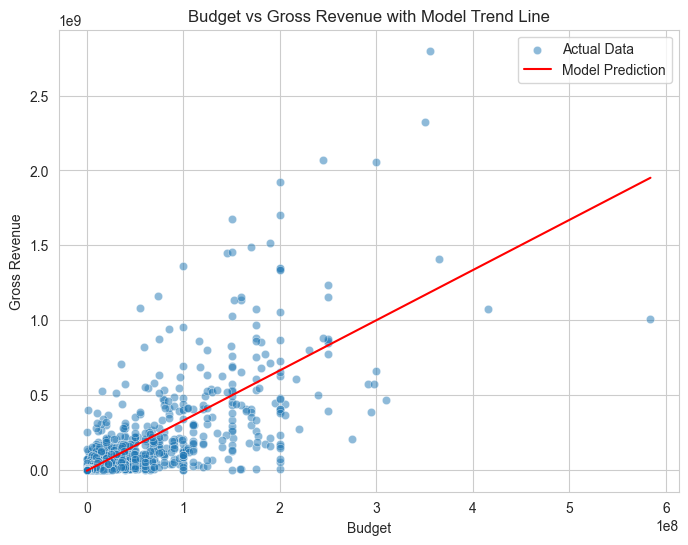

In [13]:
# Scatter plot of budget vs gross with regression line from the model
sns.scatterplot(x='budget', y='gross', data=df_clean, alpha=0.5, label='Actual Data')

# Generate model-predicted gross for a range of budget values (holding other features at their mean)
mean_vals = train_df[['title_year', 'is_usa', 'is_english', 'vote_average', 'duration']].mean()
budget_range = np.linspace(df_clean['budget'].min(), df_clean['budget'].max(), 100)
model_pred = mod.params['Intercept'] \
    + mod.params['title_year'] * mean_vals['title_year'] \
    + mod.params['is_usa'] * mean_vals['is_usa'] \
    + mod.params['is_english'] * mean_vals['is_english'] \
    + mod.params['vote_average'] * mean_vals['vote_average'] \
    + mod.params['duration'] * mean_vals['duration'] \
    + mod.params['budget'] * budget_range

plt.plot(budget_range, model_pred, color='red', label='Model Prediction')
plt.xlabel('Budget')
plt.ylabel('Gross Revenue')
plt.title('Budget vs Gross Revenue with Model Trend Line')
plt.legend()
plt.show()

### Title Year

This has the next most significant effect with a slight negative effect on gross which mean newer films are associated with slightly lower gross. Need to research more to see if this has anything to do with inflation

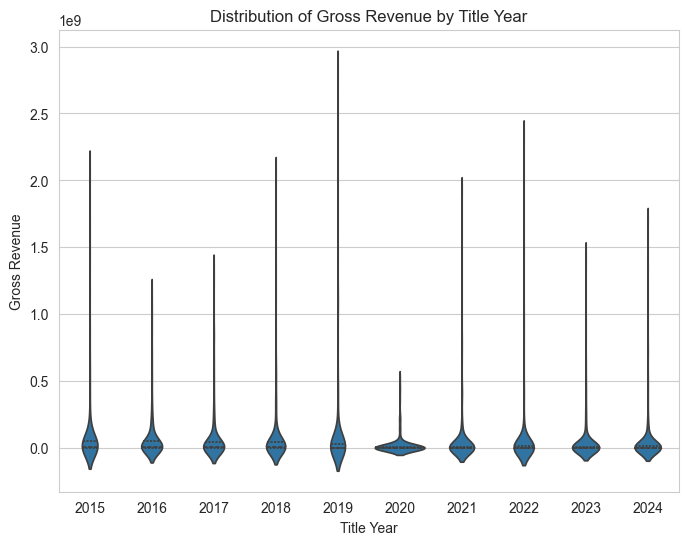

In [14]:
# Violin plot of title_year vs gross
sns.violinplot(x='title_year', y='gross', data=df_clean, inner='quartile')
plt.xlabel('Title Year')
plt.ylabel('Gross Revenue')
plt.title('Distribution of Gross Revenue by Title Year')
plt.show()


### Duration
this has a sligth negative effect on the gross of the movie. there is a point. A takeaway for duration would be that be mindful of how long a movie is.



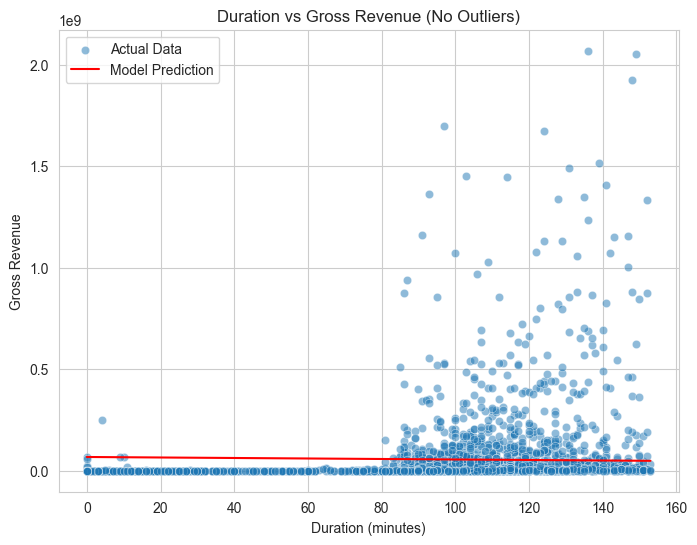

In [15]:
# Remove duration outliers (e.g., keep movies within 5th to 95th percentile of duration)
lower, upper = df_clean['duration'].quantile([0.05, 0.95])
df_no_outliers = df_clean[(df_clean['duration'] >= lower) & (df_clean['duration'] <= upper)]

# Scatter plot of duration vs gross with regression line from model (using filtered data)
sns.scatterplot(x='duration', y='gross', data=df_no_outliers, alpha=0.5, label='Actual Data')

# Generate model-predicted gross for each duration value (holding other features at their mean)
mean_vals = train_df[['budget', 'title_year', 'is_usa', 'is_english', 'vote_average']].mean()
duration_range = np.linspace(df_no_outliers['duration'].min(), df_no_outliers['duration'].max(), 100)
model_pred = mod.params['Intercept'] \
    + mod.params['budget'] * mean_vals['budget'] \
    + mod.params['title_year'] * mean_vals['title_year'] \
    + mod.params['is_usa'] * mean_vals['is_usa'] \
    + mod.params['is_english'] * mean_vals['is_english'] \
    + mod.params['vote_average'] * mean_vals['vote_average'] \
    + mod.params['duration'] * duration_range

plt.plot(duration_range, model_pred, color='red', label='Model Prediction')
plt.xlabel('Duration (minutes)')
plt.ylabel('Gross Revenue')
plt.title('Duration vs Gross Revenue (No Outliers)')
plt.legend()
plt.show()

In [16]:
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:                  gross   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     537.9
Date:                Wed, 01 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:01:43   Log-Likelihood:                -45081.
No. Observations:                2250   AIC:                         9.018e+04
Df Residuals:                    2243   BIC:                         9.022e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     4.825e+09   1.81e+09      2.666   

## Model performance

The model explains about 59% of the variance in movie gross. Given how unpredictable box office performance can be this is a reasonably strong model.

It also Identifies the leading factor in creating a new movie. The budget for the movie. Granted it has to be balanced out to figure out risk reward of the model.


## Actionable Recommendations

According to the model there are some recommendations and considerations that need to be taken into account when thinking of producing a movie

The budget has the strongest effect on the movie itself and significantly defines how much a movie can make. The budget needs to be focused on primarily. With any given budget there is a band of making anywhere from 3.224x to 3.483x (bottom 2.5% to top 97.5% confidence interval) times the investment in the budget. So having a higher but reasonable budget makes the most sense for the return on investment


There is an incentive to make movies as early as possible since over time the same movie would generate less gross revenue. For anything coming out this current year or in the future it will make less than if it was created the previous year so there is an incentive to create a movie sooner rather than later and there is a time crunch for churning out movies to maximize revenue




## Part 2: Logistic Regression - Predicting Blockbuster Status

### Question 4: Classification Model Development (12 points)

#### Q4.a) Create a binary 'blockbuster' variable where 1 = gross revenue > $100 million, 0 otherwise. What percentage of movies are blockbusters? (2 points)

In [17]:
# # Your code here
df_clean['blockbuster'] = (df_clean['gross'] > 100000000).astype(int)

blockbuster_pct = df_clean['blockbuster'].mean() * 100
print(f"Percentage of movies that are blockbusters: {blockbuster_pct:.2f}%")

Percentage of movies that are blockbusters: 12.00%


#### Q4.b) Build a logistic regression model predicting blockbuster status using the same features as Q2.a. Display the model summary. (3 points)

In [18]:

train_df, test_df = train_test_split(df_clean, test_size=0.25, random_state=42)

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

logit_mod = smf.logit("blockbuster ~ budget + title_year + is_usa + is_english + vote_average + duration", data=train_df).fit()
print(logit_mod.summary())


Training set shape: (2250, 48)
Testing set shape: (750, 48)
Optimization terminated successfully.
         Current function value: 0.166214
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:            blockbuster   No. Observations:                 2250
Model:                          Logit   Df Residuals:                     2243
Method:                           MLE   Df Model:                            6
Date:                Wed, 01 Oct 2025   Pseudo R-squ.:                  0.5345
Time:                        16:01:43   Log-Likelihood:                -373.98
converged:                       True   LL-Null:                       -803.41
Covariance Type:            nonrobust   LLR p-value:                2.952e-182
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      221.2678     70.976      3.11

#### Q4.c) Interpret the coefficient on 'budget' in words suitable for a non-technical audience. Include the odds ratio. (2 points)

In [19]:
# Get the coefficient and odds ratio for 'budget'
budget_coef = logit_mod.params['budget']
odds_ratio = np.exp(budget_coef * 1e7)  # Odds ratio for a $10 million increase in budget
print(f"Budget coefficient: {budget_coef}")
print(f"Odds ratio: {odds_ratio:.2f}")


Budget coefficient: 4.7941707995008296e-08
Odds ratio: 1.62


**Your interpretation:**
For every $10 million dollar the odds increase by 60% chance a movie is a blockbuster 

#### Q4.d) Generate predicted probabilities and create an ROC curve. What is the AUC? (3 points)

AUC: 0.9525088102030542


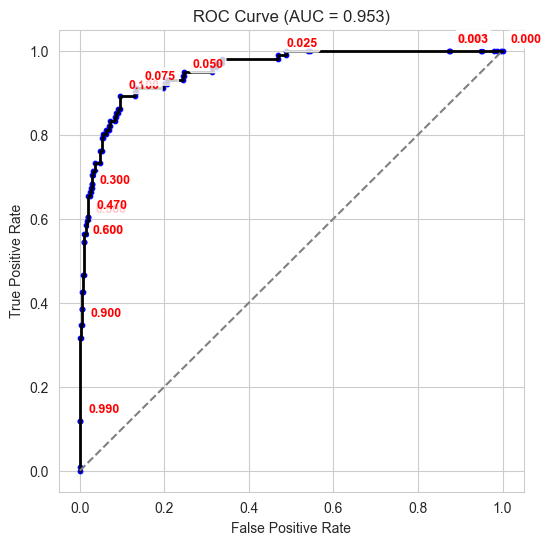

In [29]:
# Get predicted probabilities from the current logit model
test_df['score'] = logit_mod.predict(test_df)

# true labels
y_true = test_df["blockbuster"]

# predicted probabilities
y_scores = test_df["score"]

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# compute AUC
auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

# plot ROC curve
fig1, ax = plt.subplots(figsize=(6,6))
ax.plot(fpr, tpr, color="black", linewidth=2)
ax.plot([0,1], [0,1], linestyle="--", color="gray")
ax.scatter(fpr, tpr, s=10, color="blue")

for cutoff in [0.99, 0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.075, 0.6, 0.47, 0.025, 0.01, 0.001, 0.003, 0.0]:
    if cutoff == 0.0:
        idx = len(thresholds) - 1
    else:
        idx = np.argmin(np.abs(thresholds - cutoff))
    ax.text(fpr[idx] + 0.02, tpr[idx] + 0.02, f"{cutoff:.3f}", 
            fontsize=9, color='red', weight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve (AUC = {auc:.3f})")
plt.show(fig1)


#### Q4.e) Create a confusion matrix using a threshold of 0.3. Calculate precision and recall. (2 points)

In [21]:
# Your code here
from sklearn.metrics import confusion_matrix, classification_report

# y (actual) and predicted probabilities for test set
y = test_df["blockbuster"]
y_prob = test_df["score"]

# classify at cutoff = 0.3
cutoff = 0.30
y_pred = (y_prob >= cutoff).astype(int)

# confusion matrix
cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0 (No)", "Actual 1 (Yes)"],
                     columns=["Pred 0 (No)", "Pred 1 (Yes)"])
print("Confusion Matrix at cutoff = 0.30")
print(cm_df)

print("\nClassification Report:")
print(classification_report(y, y_pred, digits=3))


Confusion Matrix at cutoff = 0.30
                Pred 0 (No)  Pred 1 (Yes)
Actual 0 (No)           633            16
Actual 1 (Yes)           34            67

Classification Report:
              precision    recall  f1-score   support

           0      0.949     0.975     0.962       649
           1      0.807     0.663     0.728       101

    accuracy                          0.933       750
   macro avg      0.878     0.819     0.845       750
weighted avg      0.930     0.933     0.931       750



### Question 5: Threshold Selection for Marketing Campaign (4 points)

#### Q5.a) If you're designing an advertising campaign and want to minimize wasted marketing spend (false positives) while still catching at least 60% of blockbusters, what threshold would you recommend? Show your analysis. (4 points)

In [28]:
# Find the lowest threshold where TPR (recall) >= 0.6
desired_recall = 0.6
idx = np.where(tpr >= desired_recall)[0][0]
recommended_threshold = thresholds[idx]
print(f"Recommended threshold to catch at least 60% of blockbusters: {recommended_threshold:.3f}")

# Show confusion matrix, precision, and recall at this threshold
y_pred_recall = (y_scores >= recommended_threshold).astype(int)
cm = confusion_matrix(y, y_pred_recall)
cm_df = pd.DataFrame(cm,
                        index=["Actual 0 (No)", "Actual 1 (Yes)"],
                        columns=["Pred 0 (No)", "Pred 1 (Yes)"])
print("Confusion Matrix at recommended threshold:")
print(cm_df)
print("\nClassification Report:")
print(classification_report(y_true, y_pred_recall, digits=3))

Recommended threshold to catch at least 60% of blockbusters: 0.470
Confusion Matrix at recommended threshold:
                Pred 0 (No)  Pred 1 (Yes)
Actual 0 (No)           637            12
Actual 1 (Yes)           40            61

Classification Report:
              precision    recall  f1-score   support

           0      0.941     0.982     0.961       649
           1      0.836     0.604     0.701       101

    accuracy                          0.931       750
   macro avg      0.888     0.793     0.831       750
weighted avg      0.927     0.931     0.926       750

